## Рубежный контроль №1 (весна 2026 года)
### Выполнил студент РТ5-61Б Иванов А.А.
#### Вариант 7

Тема: Технологии разведочного анализа и обработки данных.

Задание:

Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

Для пары произвольных колонок данных построить график "Jointplot".

Датасет: Google Play Store Apps

https://www.kaggle.com/datasets/lava18/google-play-store-apps

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('googleplaystore.csv')

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# удаляем дубликаты
df = df.drop_duplicates()

df['Reviews'] = df['Reviews'].astype(int)

# заменяем Free на 0
df['Installs'] = df['Installs'].replace('Free', '0')
# убираем + и ,
df['Installs'] = df['Installs'].apply(lambda x: str(x).replace('+', '').replace(',', ''))
# преобразуем в числа 
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce').fillna(0).astype(int)

def clean_size(x):
    x = str(x)
    if x == 'Varies with device':
        return np.nan
    elif x == '1,000+':
        return np.nan
    elif 'M' in x:
        return float(x.replace('M', '').replace(',', ''))
    elif 'k' in x:
        return float(x.replace('k', '').replace(',', '')) / 1024
    else:
        try:
            return float(x)
        except ValueError:
            return np.nan
        
df['Size'] = df['Size'].apply(clean_size)

# в Price убираем $
df['Price'] = df['Price'].apply(lambda x: str(x).replace('$', '') if '$' in str(x) else x)
# 
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [ ]:
print("Пропуски до очистки:\n", df.isnull().sum())

# удаляем пропуски
df_clean = df.dropna()
print("\n Датасет после удаления: ", df_clean.shape)

Пропуски до очистки:
 App                  0
Category             0
Rating            1465
Reviews              0
Size              1527
Installs             0
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Размер датасета после удаления пропусков: (7418, 13)


Матрица корреляций:
            Rating   Reviews      Size  Installs     Price
Rating    1.000000  0.080456  0.081874  0.054350 -0.021941
Reviews   0.080456  1.000000  0.240068  0.632032 -0.010015
Size      0.081874  0.240068  1.000000  0.166979 -0.026855
Installs  0.054350  0.632032  0.166979  1.000000 -0.010627
Price    -0.021941 -0.010015 -0.026855 -0.010627  1.000000


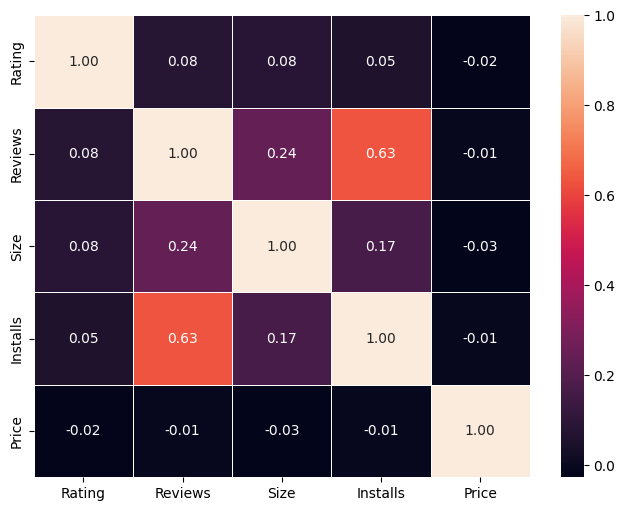

In [ ]:
# Выбираем числовые
numeric_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']
cor_matrix = df_clean[numeric_cols].corr()

print("Матрица корреляций:")
print(cor_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.show()

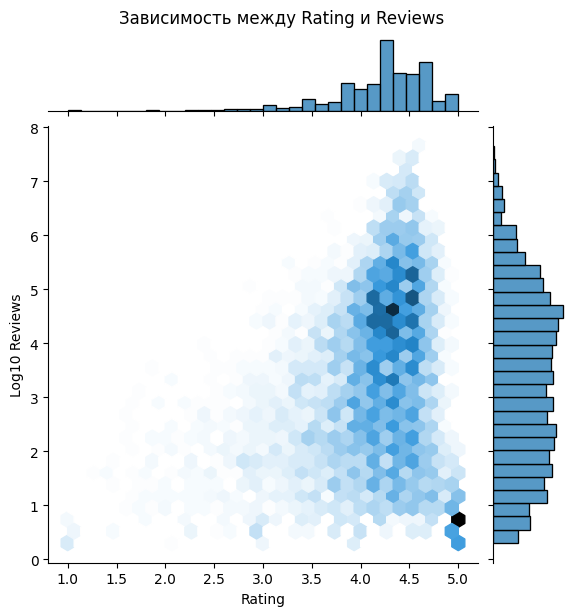

In [28]:
# логарифмируем количество отзывов (чтобы убрать влияние выбросов)
df_clean = df_clean.copy()
df_clean.loc[:, 'Log_Reviews'] = np.log10(df_clean['Reviews'] + 1)

g = sns.jointplot(
    data=df_clean,
    x='Rating', 
    y='Log_Reviews', 
    kind='hex', 
    gridsize=30,
    marginal_kws=dict(bins=30, fill=True)
)

g.set_axis_labels('Rating', 'Log10 Reviews')
g.fig.suptitle('Зависимость между Rating и Reviews', y=1.02)
plt.show()

### Выводы по анализу:

1. **Корреляционный анализ:**
   - самая сильная корреляция наблюдается между Reviews отзывами и Installs установками, так как чем больше установок, тем больше людей оставляет отзывы
   - Price имеет слабую корреляцию с количеством установок, так как платные приложения скачивают реже

2. **Возможности машинного обучения:**
   - Регрессионная модель для предсказания числа установок: Модель на основе признака Reviews будет работать весьма успешно, но также потребуются дополнительные признаки (например, Category)
